In [1]:
import numpy as np
from scipy import stats, optimize, linalg
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

# 3.3 Quasi-Newton

Quasi-Newton methods arise from the desire to use something like Newton's method for its speed but without having to compute the Hessian matrix each time. The idea is that if the Newton iteration is

$$
\theta_{n+1} = \theta_n-f^{\prime\prime}(\theta_n)^{-1}f^\prime(\theta_n)
$$

is there some other matrix that we can use to replace either $f^{\prime\prime}(\theta_n)$ or $f^{\prime\prime}(\theta_n)^{-1}$? That is can we use a revised iteration,

$$
\theta_{n+1} = \theta_n-B_n^{-1}f^\prime(\theta_n)
$$

where $B_n$ is simpler to compute but still allows the algorithm to converge quickly?

This is a challenging problem because $f^{\prime\prime}(\theta_n)$ gives us a lot of information about the surface of $f$ at $\theta_n$ and throwing out this information results in, well, a severe loss of information.

The idea with Quasi-Newton is to find a solution $B_n$ to the problem

$$
f^\prime(\theta_n)-f^\prime(\theta_{n-1}) = B_n (\theta_n-\theta_{n-1}).
$$

The equation above is sometimes referred to as the *secant equation*. Note first that this requires us to store two values, $\theta_n$ and $\theta_{n-1}$. Also, in one dimension, the solution is trivial: we can simply divide the left-hand-side by $\theta_n-\theta_{n-1}$. However, in more than one dimension, there exists an infinite number of solutions and we need some way to constrain the problem to arrive at a sensible answer.

The key to Quasi-Newton approaches in general is that while we initially may not have much information about $f$, with each iteration we obtain just a little bit more. Specifically, we learn more about the Hessian matrix through successive differences in $f^\prime$. Therefore, with each iteration we can incorporate this newly obtained information into our estimate of the Hessian matrix. The constraints placed on the matrix $B_n$ is that it be *symmetric* and that it be close to $B_{n-1}$. These constraints can be satisfied by updating $B_n$ via the addition of rank one matrices.

If we let $y_n = f^\prime(\theta_n)-f^\prime(\theta_{n-1})$ and $s_n = \theta_n-\theta_{n-1}$, then the secant equation is $y_n = B_ns_n$. One updating procedure for $B_n$ is

$$
B_{n} = B_{n-1} + \frac{y_ny_n^\prime}{y_n^\prime s_n}
- \frac{B_{n-1}s_ns_n^\prime B_{n-1}^\prime}{s_n^\prime B_{n-1}s_n}
$$

The above updating procedure was developed by Broyden, Fletcher, Goldfarb, and Shanno (BFGS). An analogous approach, which solves the secant equation $H_n y_n = s_n$, was proposed by Davidon, Fletcher, and Powell (DFP).

Note that in the case of the BFGS method, we actually use $B_n^{-1}$ in the Newton update. However, it is not necessary to solve for $B_{n}$ and then invert it directly. We can directly update $B_{n-1}^{-1}$ to produce $B_{n}^{-1}$ via the [Sherman-Morrison update formula](https://en.wikipedia.org/wiki/Sherman%E2%80%93Morrison_formula). This formula allows us to generate the new inverse matrix by using the previous inverse and some matrix multiplication.

### Quasi-Newton Methods in Python

Quasi-Newton methods are available in Python via `scipy.optimize.minimize`, a general-purpose optimization function supporting many methods. In this section we focus on the `"BFGS"` and `"L-BFGS-B"` methods.

#### Example: Truncated Normal and Mixture of Normal Distributions

For this example we use daily average NO2 concentrations for monitors in Washington State (data derived from the U.S. EPA Air Quality System, 2016). A kernel density estimate of the NO2 data shows the following distribution.

n = 12500, mean = 13.52, std = 8.10


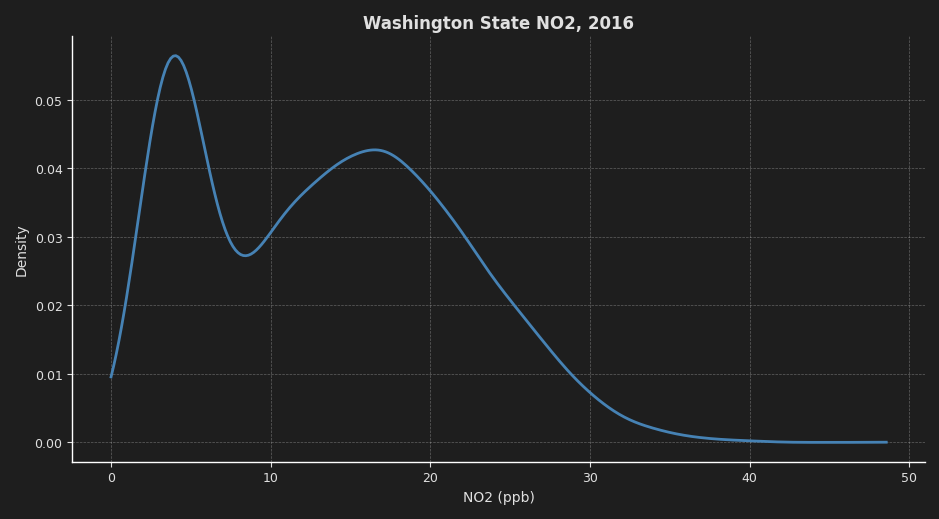

In [2]:
no2 = np.loadtxt('../data/no2_wa_2016.csv', skiprows=1)
print(f"n = {len(no2)}, mean = {no2.mean():.2f}, std = {no2.std():.2f}")

from scipy.stats import gaussian_kde
xgrid = np.linspace(0, no2.max(), 300)
kde = gaussian_kde(no2)

fig, ax = plt.subplots()
ax.plot(xgrid, kde(xgrid), color='steelblue')
ax.set_xlabel('NO2 (ppb)')
ax.set_ylabel('Density')
ax.set_title('Washington State NO2, 2016')
plt.tight_layout()

As an initial stab at characterizing the distribution of the NO2 values we will try to fit a truncated Normal model to the data. The truncated Normal can make sense for these kinds of data because they are strictly positive, making a standard Normal distribution inappropriate.

For the truncated normal, truncated from below at $0$, the density of the data is

$$
f(x) = \frac{\frac{1}{\sigma}\varphi\left(\frac{x-\mu}{\sigma}\right)}{\int_0^\infty \frac{1}{\sigma}\varphi\left(\frac{x-\mu}{\sigma}\right)\,dx}.
$$

The unknown parameters are $\mu$ and $\sigma$. We estimate them by minimizing the *negative* log-likelihood of the data. In Python, `scipy.stats.truncnorm` provides the log-density of a truncated Normal directly.

In [3]:
def nll_tnorm(p, x):
    """Negative log-likelihood for truncated Normal (truncated below at 0)."""
    mu, sigma = p
    if sigma <= 0:
        return 1e10
    a = (0.0 - mu) / sigma        # lower truncation point in standard-normal units
    logpdf = stats.truncnorm.logpdf(x, a=a, b=np.inf, loc=mu, scale=sigma)
    if not np.all(np.isfinite(logpdf)):
        return 1e10
    return -np.sum(logpdf)

We pass `nll_tnorm` to `scipy.optimize.minimize` using `method='BFGS'`. We use starting values of $\mu=1$ and $\sigma=5$. We also set `hess_inv` via BFGS so we can later compute standard errors.

In [4]:
res_bfgs = optimize.minimize(
    nll_tnorm, x0=[1.0, 5.0], args=(no2,),
    method='BFGS',
    options={'disp': False}
)

print(f"par       : mu={res_bfgs.x[0]:.5f}, sigma={res_bfgs.x[1]:.5f}")
print(f"value     : {res_bfgs.fun:.3f}")
print(f"iterations: {res_bfgs.nit}")
print(f"success   : {res_bfgs.success}")
print(f"message   : {res_bfgs.message}")

par       : mu=11.03091, sigma=9.96731
value     : 42949.088
iterations: 17
success   : True
message   : Optimization terminated successfully.


The `minimize` function returns a result object. The first thing to check is `success`: if `True`, the optimizer converged. Because we used unconstrained BFGS, the algorithm was free to explore negative $\sigma$ values during the search. In order to constrain the search we can use `"L-BFGS-B"` — a limited-memory BFGS variant with box constraints — and set a lower bound of $0$ on both parameters.

In [5]:
res_lbfgs = optimize.minimize(
    nll_tnorm, x0=[1.0, 5.0], args=(no2,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (1e-6, None)]
)

print(f"par       : mu={res_lbfgs.x[0]:.5f}, sigma={res_lbfgs.x[1]:.5f}")
print(f"value     : {res_lbfgs.fun:.3f}")
print(f"iterations: {res_lbfgs.nit}")
print(f"success   : {res_lbfgs.success}")
print(f"message   : {res_lbfgs.message}")

par       : mu=11.03091, sigma=9.96731
value     : 42949.088
iterations: 18
success   : True
message   : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


We can see that the two methods agree. The maximum likelihood estimate of $\mu$ is about 11.03 and the estimate of $\sigma$ is about 9.97. If we wanted to obtain asymptotic standard errors for these parameters, we could use the inverse Hessian returned by the BFGS run.

In [6]:
# BFGS stores an approximation to the inverse Hessian in hess_inv
se = np.sqrt(np.diag(res_bfgs.hess_inv))
print(f"Standard errors: mu={se[0]:.4f}, sigma={se[1]:.4f}")

Standard errors: mu=0.1482, sigma=0.1036


In this case though, we don't care much for the standard errors so we will move on.

We can plot the original density smooth of the data versus the fitted truncated Normal model to see how well we characterize the distribution.

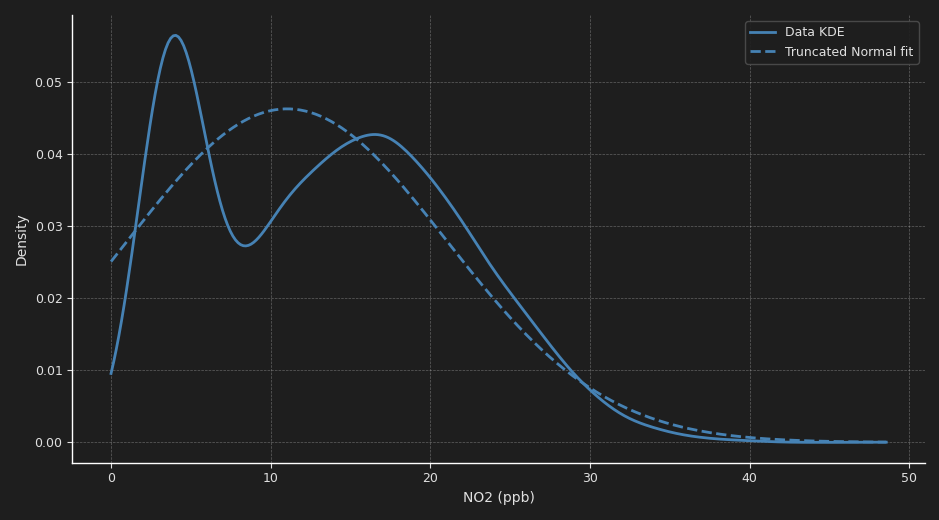

In [7]:
mu_hat, sig_hat = res_lbfgs.x
a_hat = (0.0 - mu_hat) / sig_hat
dens_fit = stats.truncnorm.pdf(xgrid, a=a_hat, b=np.inf, loc=mu_hat, scale=sig_hat)

fig, ax = plt.subplots()
ax.plot(xgrid, kde(xgrid), color='steelblue', label='Data KDE')
ax.plot(xgrid, dens_fit, color='steelblue', linestyle='--', label='Truncated Normal fit')
ax.set_xlabel('NO2 (ppb)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()

It's not a great fit. Looking at the density smooth of the data, it's clear that there are two modes to the data, suggesting that a truncated Normal might not be sufficient to characterize the data.

One alternative in this case would be a mixture of two Normals, which might capture the two modes. For a two-component mixture, the density for the data would be

$$
f(x)
=
\lambda\frac{1}{\sigma_1}\varphi\left(\frac{x-\mu_1}{\sigma_1}\right) +
(1-\lambda)\frac{1}{\sigma_2}\varphi\left(\frac{x-\mu_2}{\sigma_2}\right).
$$

Commonly, we see that this model is fit using more complex algorithms like the EM algorithm or Markov chain Monte Carlo methods. While those methods do provide greater stability in the estimation process (as we will see later), we can in fact use Newton-type methods to maximize the likelihood directly with a little care.

We write the negative log-likelihood for the mixture model.

In [8]:
def nll_mix(p, x):
    """Negative log-likelihood for 2-component Normal mixture."""
    mu1, mu2, s1, s2, lam = p
    if s1 <= 0 or s2 <= 0 or not (0 < lam < 1):
        return 1e10
    lik = lam * stats.norm.pdf(x, mu1, s1) + (1 - lam) * stats.norm.pdf(x, mu2, s2)
    lik = np.maximum(lik, 1e-300)   # guard against log(0)
    return -np.sum(np.log(lik))

We pass the `nll_mix` function into `optimize.minimize` with an initial vector of parameters. We use `"L-BFGS-B"` to specify a lower bound of $0$ for all parameters and an upper bound of $1$ for the $\lambda$ parameter.

In [9]:
pstart = np.array([5.0, 15.0, 2.0, 5.0, 0.5])

res_mix = optimize.minimize(
    nll_mix, x0=pstart, args=(no2,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (1e-6, None),
            (1e-6, None), (1e-6, None),
            (1e-6, 1 - 1e-6)]
)

mu1h, mu2h, s1h, s2h, lamh = res_mix.x
print(f"par : mu1={mu1h:.4f}, mu2={mu2h:.4f}, s1={s1h:.4f}, s2={s2h:.4f}, lam={lamh:.4f}")
print(f"value: {res_mix.fun:.3f}")
print(f"success: {res_mix.success}")
print(f"message: {res_mix.message}")

par : mu1=3.8795, mu2=16.7345, s1=1.5944, s2=6.7396, lam=0.2500
value: 42316.989
success: True
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


The algorithm runs without any warnings or messages. We can overlay the fitted model on to the density smooth to see how the model does.

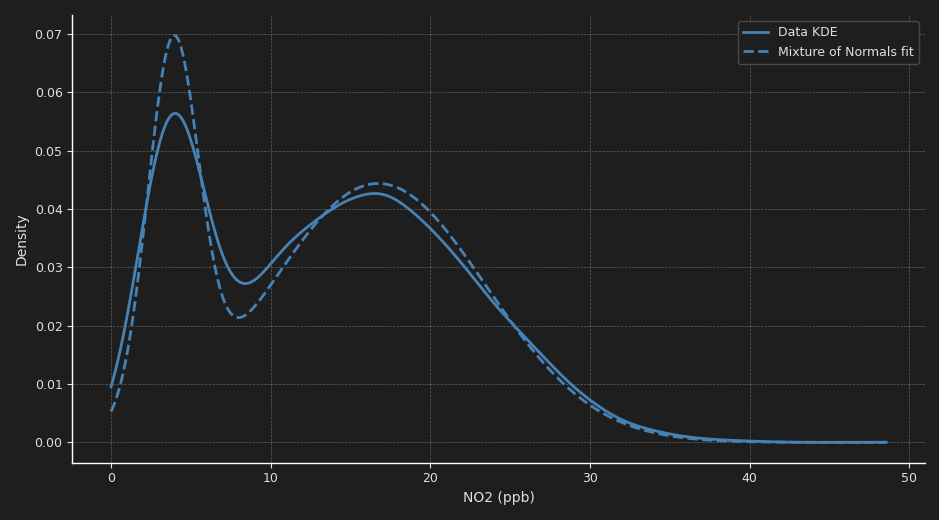

In [10]:
mu1h, mu2h, s1h, s2h, lamh = res_mix.x
dens_mix = lamh * stats.norm.pdf(xgrid, mu1h, s1h) + (1 - lamh) * stats.norm.pdf(xgrid, mu2h, s2h)

fig, ax = plt.subplots()
ax.plot(xgrid, kde(xgrid), color='steelblue', label='Data KDE')
ax.plot(xgrid, dens_mix, color='steelblue', linestyle='--', label='Mixture of Normals fit')
ax.set_xlabel('NO2 (ppb)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()

The fit is still not wonderful, but at least this model captures roughly the locations of the two modes in the density. Also, it would seem that the model captures the tail of the density reasonably well, although this would need to be checked more carefully by looking at the quantiles.

Finally, as with most models and optimization schemes, it's usually a good idea to vary the starting points to see if our current estimate is a local mode.

In [11]:
pstart2 = np.array([2.0, 18.0, 3.0, 5.0, 0.2])

res_mix2 = optimize.minimize(
    nll_mix, x0=pstart2, args=(no2,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (1e-6, None),
            (1e-6, None), (1e-6, None),
            (1e-6, 1 - 1e-6)]
)

mu1h2, mu2h2, s1h2, s2h2, lamh2 = res_mix2.x
print(f"par : mu1={mu1h2:.4f}, mu2={mu2h2:.4f}, s1={s1h2:.4f}, s2={s2h2:.4f}, lam={lamh2:.4f}")
print(f"value: {res_mix2.fun:.3f}")
print("Here we see that with a slightly different starting point we get the same minimum NLL.")

par : mu1=3.8795, mu2=16.7345, s1=1.5944, s2=6.7396, lam=0.2500
value: 42316.989
Here we see that with a slightly different starting point we get the same minimum NLL.
